In [1]:
# =============================
# 🔧 STEP 1: INSTALL DEPENDENCIES
# =============================
!pip install pandas matplotlib nltk

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.1 MB 11.0 MB/s eta 0:00:01
   ------------------ --------------------- 3.7/8.1 MB 10.1 MB/s eta 0:00:01
   ------------------ --------------------- 3.7/8.1 MB 10.1 MB/s eta 0:00:01
   ------------------ --------------------- 3.7/8.1 MB 10.1 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.1 MB 6.5 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 7.3 MB/s  0:00:01
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 36.3 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 21.0 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ---------------------------------------  6.8/7.0 MB 34.6 MB/s eta 0:00:01
   ---------------------------------------

In [2]:
# =============================
# 📦 STEP 2: IMPORT LIBRARIES
# =============================
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
import re

In [3]:
# =============================
# ⚙️ STEP 3: CONFIGURATION
# =============================
CSV_PATH = "Human Review.csv"        # Path to your input CSV file
TEXT_COLUMN = None                   # Set manually (e.g., "review_text") or leave None for auto-detection
OUTPUT_CSV = "sentiment_scored.csv"  # Output file for row-level sentiment scores
SUMMARY_CSV = "sentiment_summary.csv" # Output file for sentiment summary
PLOT_PATH = "sentiment_distribution.png"  # File path to save sentiment distribution plot


In [4]:
# =============================
# ⚙️ STEP 4: DEFINE STOPWORDS
# =============================
_STOP = {
    "a","an","the","and","or","but","if","then","else","for","to","in","on","of","at","by","is",
    "am","are","was","were","be","been","being","it","this","that","these","those","as","with",
    "from","about","into","over","after","before","so","such","than","too","very","can","could",
    "would","should","do","does","did","done","doing","i","me","my","we","us","our","you","your",
    "he","him","his","she","her","they","them","their","there","here","up","down","out","not","no",
    "yes","ok","okay"
}

In [5]:
# =============================
# 🧹 STEP 5: BASIC TEXT CLEANING FUNCTION
# =============================
def clean_basic(text: str) -> str:
    if not isinstance(text, str):
        return ""
    s = text.lower()
    s = re.sub(r"http[s]?://\S+|www\.\S+", " ", s)  # Remove URLs
    s = re.sub(r"\s+", " ", s).strip()               # Remove extra whitespace
    return s

In [6]:
# =============================
# 🔍 STEP 6: AUTO-DETECT TEXT COLUMN
# =============================
def pick_text_column(df: pd.DataFrame) -> str:
    candidates = []
    for c in df.columns:
        if df[c].dtype == "object":
            s = df[c].dropna().astype(str)
            if s.empty:
                continue
            lens = s.str.split().apply(lambda toks: sum(1 for t in toks if t.lower() not in _STOP))
            score = lens.mean()
            candidates.append((score, c))
    if not candidates:
        raise ValueError("No text-like (object) columns found. Set TEXT_COLUMN manually.")
    candidates.sort(reverse=True)
    return candidates[0][1]

In [7]:
# =============================
# 🧮 STEP 7: BUCKETIZE COMPOUND SCORE INTO SENTIMENT LABELS
# =============================
def bucketize(compound: float) -> str:
    if compound <= -0.75: return "Very Negative"
    if compound <= -0.5:  return "Negative"
    if compound <= -0.05: return "Slightly Negative"
    if compound <  0.05:  return "Neutral"
    if compound <  0.5:   return "Slightly Positive"
    if compound <  0.75:  return "Positive"
    return "Very Positive"

In [8]:
# =============================
# 🚀 STEP 8: MAIN ANALYSIS PIPELINE
# =============================
# 1. Ensure VADER lexicon is available
try:
    nltk.data.find("sentiment/vader_lexicon.zip")
except LookupError:
    nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to C:\Users\Lazim
[nltk_data]     Istiak\AppData\Roaming\nltk_data...


In [2]:
# 2. Initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()

NameError: name 'SentimentIntensityAnalyzer' is not defined

In [3]:
# 3. Load CSV file
df = pd.read_csv(CSV_PATH, encoding="utf-8", engine="python", on_bad_lines="skip")

NameError: name 'pd' is not defined

In [11]:
# 4. Auto-detect the main text column if not set
col = TEXT_COLUMN or pick_text_column(df)
print(f"Using text column: {col}")

Using text column: Data scrapping of Times Square Restaurants


In [12]:
# 5. Clean text and compute sentiment scores
texts = df[col].fillna("").astype(str).map(clean_basic)
scores = texts.apply(sia.polarity_scores)

In [13]:
# 6. Merge original data with sentiment scores
scored = pd.concat([df.reset_index(drop=True), scores.apply(pd.Series)], axis=1)

In [14]:
# 7. Add sentiment label
scored["sentiment_label"] = scored["compound"].apply(bucketize)

In [15]:
# 8. Save row-level sentiment results
scored.to_csv(OUTPUT_CSV, index=False)
print(f"✅ Saved row-level scores -> {OUTPUT_CSV}")

✅ Saved row-level scores -> sentiment_scored.csv


In [16]:
# =============================
# 📊 STEP 9: CREATE SUMMARY TABLE
# =============================
summary = (
    scored["sentiment_label"]
    .value_counts()
    .rename_axis("sentiment_label")
    .reset_index(name="count")
    .sort_values("sentiment_label")
)

summary["share"] = (summary["count"] / summary["count"].sum()).round(4)
summary.to_csv(SUMMARY_CSV, index=False)
print(f"✅ Saved summary -> {SUMMARY_CSV}")


✅ Saved summary -> sentiment_summary.csv


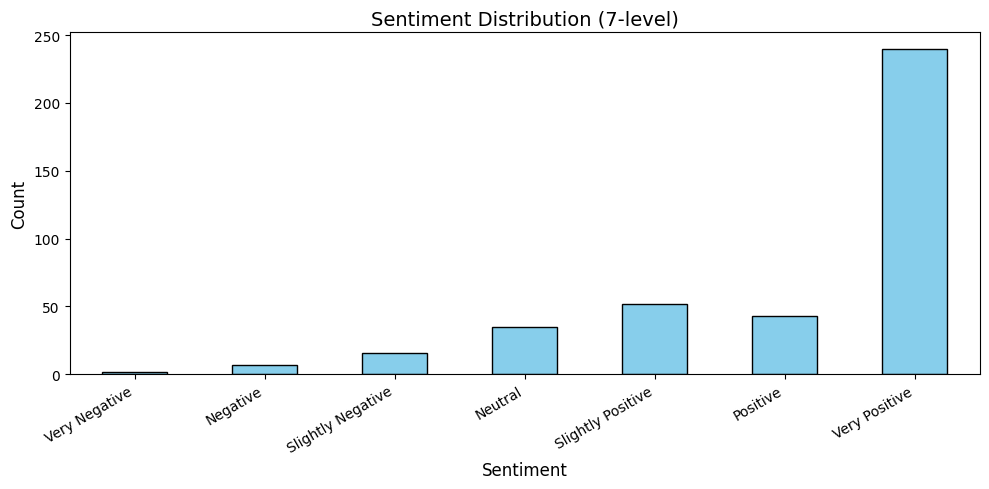

✅ Saved plot -> sentiment_distribution.png


In [17]:
# =============================
# 📈 STEP 10: PLOT SENTIMENT DISTRIBUTION
# =============================
order = [
    "Very Negative","Negative","Slightly Negative","Neutral",
    "Slightly Positive","Positive","Very Positive"
]
counts = scored["sentiment_label"].value_counts().reindex(order, fill_value=0)

plt.figure(figsize=(10,5))
counts.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Sentiment Distribution (7-level)", fontsize=14)
plt.xlabel("Sentiment", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=180, bbox_inches="tight")
plt.show()
print(f"✅ Saved plot -> {PLOT_PATH}")